# Principal Component Analysis(PCA)

### What Is PCA?

PCA is a <span style="color:#1f77b4">**linear**</span> dimensionality-reduction technique that <span style="color:#ff7f0e">**rotates**</span> the data into a new coordinate system. In the new coordinate system, the first axis (i.e., principal component 1) captures the largest variance. Each subsequent axis captures the largest remaining variance.

The idea is to <span style="color:#2ca02c">**compress**</span> high-dimensional data while losing as little information as possible by projecting onto the top-variance directions.

---

### How It Works

Conceptual algorithm (Eckart–Young):

1. <span style="color:#1f77b4">**Standardize & center**</span> the data matrix $X\in\mathbb{R}^{n\times p}$.

2. <span style="color:#1f77b4">**Compute covariance**</span> $ \Sigma = \tfrac{1}{n-1} X^\top X$.

3. <span style="color:#ff7f0e">**Eigenvalue Decomposition (or Singular Value Decompositon)**</span>

   $$
   \Sigma = V\Lambda V^\top,\qquad \text{or } X = U\Sigma V^\top.
   $$

   *Columns of* $V$ (*right singular vectors*) are principal directions; diagonal $\Lambda$ holds variances $\lambda_j$.

4. **Sort** eigenvalues in a descending order $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_p$.

5. <span style="color:#2ca02c">**Select the top $d$ components**</span> (keep enough to explain a chosen proportion of variance).

6. <span style="color:#2ca02c">**Project**</span> data to low-dimensional space: $ Z = X V_{1:d}$.

---
### Some terminologies

- PC loadings are correlation of each variable with the corresponding principal components  

- PC scores describe where each data point falls along that one PC, and they are entries in each PC.  

---

### Pros and Cons

✅ Great for **noise filtering**, compression, and pre-whitening before clustering or regression.  
✅ Removes feature **multicollinearity**; boosts linear model stability.  
✅ Scree plot / variance ratio offers a **data-driven** way to pick dimensionality.  

❌ **Linear**—misses curved manifolds unless you switch to kernel variants.  
❌ **Interpretability** can suffer: loadings are combinations of many original features.  
❌ Sensitive to **scaling**: always standardize or results skew toward large-variance units.  

---

### Key Hyper-parameters (`sklearn.decomposition.PCA`)

| Symbol in `sklearn` | Meaning                                        | Typical starter value                   |
| ------------------- | ---------------------------------------------- | --------------------------------------- |
| `n_components`      | # PCs or variance fraction to keep             | `0.9` (90 % var) or integer             |
| `svd_solver`        | `"auto"`, `"full"`, `"randomized"`, `"arpack"` | `"auto"` (delegates)                    |
| `whiten`            | Scale PCs to unit variance                     | `False` (set `True` for some ML models) |

---


### Example: PCA as a rotation in 2D

We use a small simulated dataset so the geometry is visible. The cloud is centered at zero and stretched along a diagonal direction; PCA will recover that direction from the data.


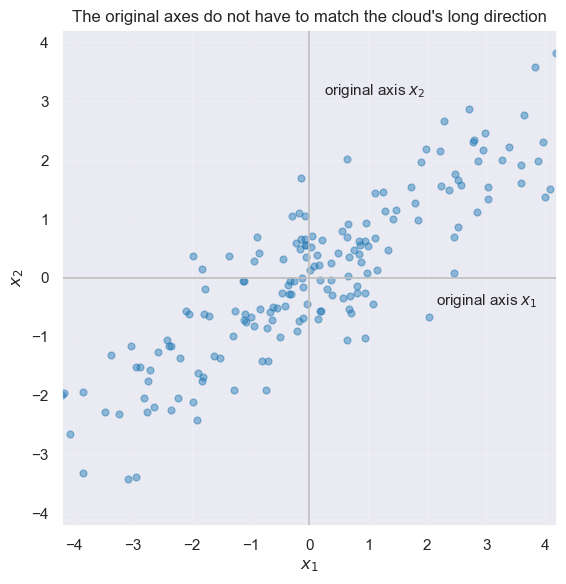

In [8]:
# Create and show a centered 2D cloud.
import numpy as np
import matplotlib.pyplot as plt

rng_pca2d = np.random.default_rng(7)
n_pca2d = 180
true_angle = np.deg2rad(32)
rotation_true = np.array([
    [np.cos(true_angle), -np.sin(true_angle)],
    [np.sin(true_angle),  np.cos(true_angle)],
])

X_pca2d = rng_pca2d.normal(size=(n_pca2d, 2)) @ np.diag([2.8, 0.65]) @ rotation_true.T
X_pca2d = X_pca2d - X_pca2d.mean(axis=0)

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(X_pca2d[:, 0], X_pca2d[:, 1], s=24, alpha=0.45, color="#1f77b4")
ax.axhline(0, color="0.75", linewidth=1.2)
ax.axvline(0, color="0.75", linewidth=1.2)
ax.annotate("original axis $x_1$", xy=(3.8, 0), xytext=(2.15, -0.45), fontsize=11)
ax.annotate("original axis $x_2$", xy=(0, 3.8), xytext=(0.25, 3.1), fontsize=11)
ax.set_xlim(-4.2, 4.2)
ax.set_ylim(-4.2, 4.2)
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("The original axes do not have to match the cloud's long direction")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


To decide whether a direction is useful, project the data onto that direction. Each point casts a shadow onto the candidate axis. If the shadows are widely spread out, that axis preserves a lot of variation. If the shadows bunch together, that axis loses much of the structure.

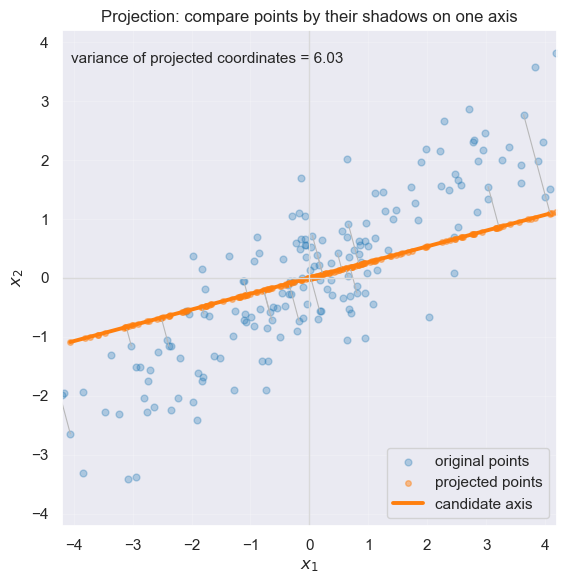

In [9]:
# Show projections onto one candidate axis.
candidate_angle = np.deg2rad(15)
u_candidate = np.array([np.cos(candidate_angle), np.sin(candidate_angle)])
projected_candidate = np.outer(X_pca2d @ u_candidate, u_candidate)
captured_candidate = np.var(X_pca2d @ u_candidate, ddof=1)

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(X_pca2d[:, 0], X_pca2d[:, 1], s=24, alpha=0.30, color="#1f77b4", label="original points")
ax.scatter(projected_candidate[:, 0], projected_candidate[:, 1], s=16, alpha=0.45, color="#ff7f0e", label="projected points")

for point, proj in zip(X_pca2d[::10], projected_candidate[::10]):
    ax.plot([point[0], proj[0]], [point[1], proj[1]], color="0.72", linewidth=0.8)

line_len = 4.2
ax.plot(
    [-line_len * u_candidate[0], line_len * u_candidate[0]],
    [-line_len * u_candidate[1], line_len * u_candidate[1]],
    color="#ff7f0e", linewidth=2.8, label="candidate axis"
)
ax.axhline(0, color="0.85", linewidth=1.0)
ax.axvline(0, color="0.85", linewidth=1.0)
ax.text(-4.05, 3.65, f"variance of projected coordinates = {captured_candidate:.2f}", fontsize=11)
ax.set_xlim(-4.2, 4.2)
ax.set_ylim(-4.2, 4.2)
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Projection: compare points by their shadows on one axis")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


Now repeat the projection calculation for many possible directions. Each direction gives one number: the variance of the projected coordinates PCA chooses the direction where this number is largest. That direction becomes <span style="color:#1f77b4">**PC1**</span>.

Note: In practice, we do **not** use exhaustive search to find the PCs. We use [singular-value decomposition (SVD)](https://en.wikipedia.org/wiki/Singular_value_decomposition) instead. 


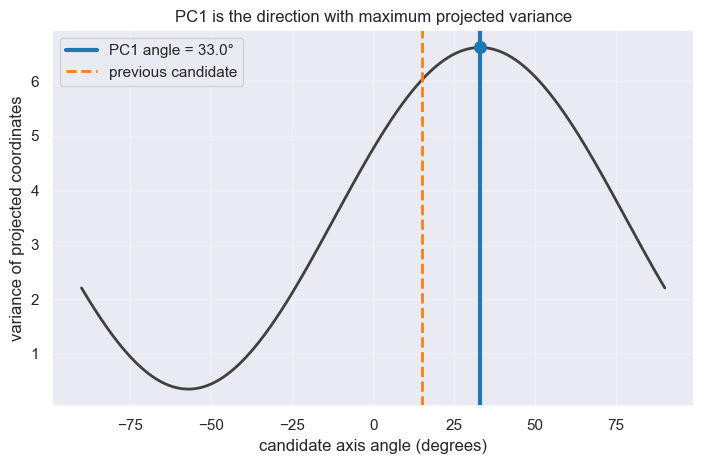

In [10]:
# Compare projected variance across many directions.
cov_pca2d = np.cov(X_pca2d, rowvar=False)
eigvals_pca2d, eigvecs_pca2d = np.linalg.eigh(cov_pca2d)
order_pca2d = np.argsort(eigvals_pca2d)[::-1]
eigvals_pca2d = eigvals_pca2d[order_pca2d]
eigvecs_pca2d = eigvecs_pca2d[:, order_pca2d]

pc1 = eigvecs_pca2d[:, 0]
pc2 = eigvecs_pca2d[:, 1]
pc1_angle = np.rad2deg(np.arctan2(pc1[1], pc1[0]))
if pc1_angle > 90:
    pc1_angle -= 180
if pc1_angle < -90:
    pc1_angle += 180

angle_grid = np.linspace(-90, 90, 361)
projected_variance = []
for angle in angle_grid:
    theta = np.deg2rad(angle)
    u = np.array([np.cos(theta), np.sin(theta)])
    projected_variance.append(np.var(X_pca2d @ u, ddof=1))
projected_variance = np.array(projected_variance)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.plot(angle_grid, projected_variance, color="0.25", linewidth=2)
ax.axvline(pc1_angle, color="#1f77b4", linewidth=3, label=f"PC1 angle = {pc1_angle:.1f}°")
ax.scatter([pc1_angle], [projected_variance.max()], color="#1f77b4", s=70, zorder=3)
ax.axvline(15, color="#ff7f0e", linewidth=2, linestyle="--", label="previous candidate")
ax.set_xlabel("candidate axis angle (degrees)")
ax.set_ylabel("variance of projected coordinates")
ax.set_title("PC1 is the direction with maximum projected variance")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


After PC1 is found, the second principal component in the 2D example is forced: it is the perpendicular direction. This is the rotation idea. PCA replaces the original axes $(x_1, x_2)$ with a new perpendicular coordinate system $(\mathrm{PC1}, \mathrm{PC2})$. The points are the same points; we are changing the axes used to describe them.


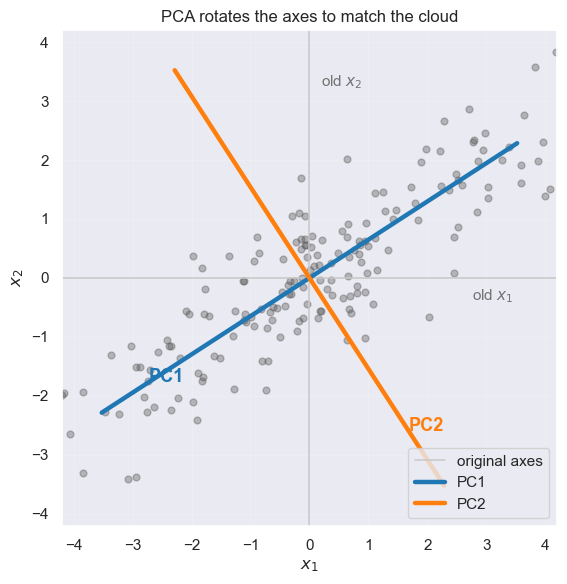

In [11]:
# Draw the PCA-rotated coordinate system.
fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(X_pca2d[:, 0], X_pca2d[:, 1], s=24, alpha=0.38, color="0.35")

line_len = 4.2
ax.axhline(0, color="0.78", linewidth=1.1, label="original axes")
ax.axvline(0, color="0.78", linewidth=1.1)
ax.plot([-line_len * pc1[0], line_len * pc1[0]], [-line_len * pc1[1], line_len * pc1[1]],
        color="#1f77b4", linewidth=3.2, label="PC1")
ax.plot([-line_len * pc2[0], line_len * pc2[0]], [-line_len * pc2[1], line_len * pc2[1]],
        color="#ff7f0e", linewidth=3.2, label="PC2")

ax.text(3.25 * pc1[0], 3.25 * pc1[1], "PC1", color="#1f77b4", fontsize=13, weight="bold")
ax.text(3.10 * pc2[0], 3.10 * pc2[1], "PC2", color="#ff7f0e", fontsize=13, weight="bold")
ax.text(2.75, -0.38, "old $x_1$", color="0.45", fontsize=11)
ax.text(0.20, 3.25, "old $x_2$", color="0.45", fontsize=11)

ax.set_xlim(-4.2, 4.2)
ax.set_ylim(-4.2, 4.2)
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("PCA rotates the axes to match the cloud")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.18)
plt.tight_layout()
plt.show()


### PCA on Spotify-like numeric features

Now we apply the same rotation-and-projection idea to a higher-dimensional data set. The data have more than two original axes, but the interpretation is the same: PCA finds new directions that capture variation, then we decide how many of those directions to keep.


In [1]:
# --- Step 0 (setup): create a small Spotify-like numeric data set ---------
# The original 2025 notebook used a large Spotify CSV. For the upload package,
# we generate a reproducible stand-in so the notebook is self-contained.
import pandas as pd
import numpy as np

_rng = np.random.default_rng(42)
_n = 5_000
_genre = _rng.integers(0, 3, _n)                    # three latent audio profiles
_profiles = np.array([
    [0.8, 0.9, -5.0, 0.10, 0.10, 0.05, 0.20, 0.75, 125.0, 210_000],
    [0.4, 0.3, -14.0, 0.04, 0.75, 0.25, 0.15, 0.35,  85.0, 240_000],
    [0.6, 0.6, -8.0, 0.18, 0.30, 0.10, 0.35, 0.55, 105.0, 195_000],
])
_scales = np.array([0.12, 0.12, 2.0, 0.04, 0.15, 0.10, 0.08, 0.15, 12.0, 25_000])
_feat = _profiles[_genre] + _rng.normal(0, _scales, size=(_n, 10))

num_cols = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms"
]
spotify = pd.DataFrame(_feat, columns=num_cols)
for col in ["danceability", "energy", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"]:
    spotify[col] = spotify[col].clip(0, 1)
spotify["tempo"] = spotify["tempo"].clip(45, 210)
spotify["duration_ms"] = spotify["duration_ms"].clip(60_000, 420_000)
spotify["popularity"] = (30 + 20 * _genre + _rng.normal(0, 8, _n)).clip(0, 100)

# Keep just numeric audio columns. X is n x p: 5000 tracks, 10 numeric features.
X = spotify[num_cols].dropna()


In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 2. Standardise: PCA assumes zero-mean / unit-variance
# --- Step 1 of the algorithm: standardize & center X ---------------------
# (unscaled features would let one unit, e.g. duration in ms, dominate PC1)
X_std = StandardScaler().fit_transform(X)

# 3. Fit PCA on the scaled matrix
# --- Steps 2-4 of the algorithm, done inside PCA().fit():
#     covariance -> eigen/SVD decomposition -> eigenvalues sorted descending
pca = PCA().fit(X_std)



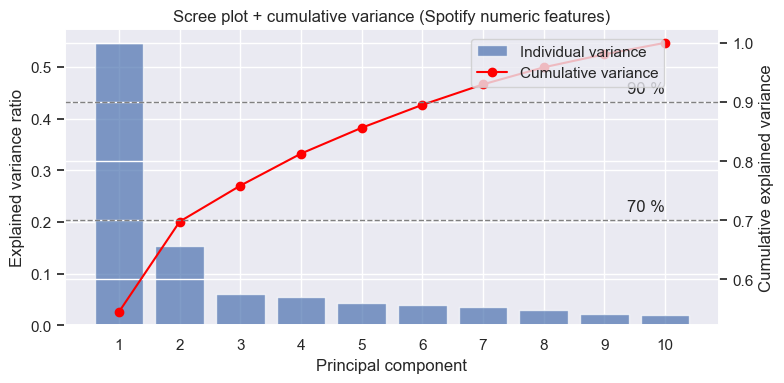

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

# --- Step 5 of the algorithm: choose how many components d to keep -------
# The scree plot shows each eigenvalue's share of total variance
# (explained_variance_ratio_) and the cumulative share.
# ---  PLOT  -----------------------------------------------------------
expl_var   = pca.explained_variance_ratio_      # eigenvalue shares, sorted (Step 4)
cum_var    = expl_var.cumsum()
pcs        = range(1, len(expl_var) + 1)

fig, ax1 = plt.subplots(figsize=(8, 4))

# bars = variance per PC
ax1.bar(pcs, expl_var, alpha=0.7, label="Individual variance")
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance ratio")
ax1.set_xticks(pcs)

# secondary y-axis for cumulative curve
ax2 = ax1.twinx()
ax2.plot(pcs, cum_var, color="red", marker="o", label="Cumulative variance")
ax2.set_ylabel("Cumulative explained variance")

# horizontal helper lines (e.g. 70 %, 90 %)
for thresh in [0.7, 0.9]:
    ax2.axhline(thresh, ls="--", lw=1, color="grey")
    ax2.text(len(pcs), thresh + 0.015, f"{thresh*100:.0f} %", ha="right")

# legends & title
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.9))
plt.title("Scree plot + cumulative variance (Spotify numeric features)")
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# --- Step 6 of the algorithm: project X onto the top d=2 components ------
# pc_scores = Z = X_std V_{1:2}; each row is a track's coordinates on PC1/PC2
pc_scores   = pca.transform(X_std)[:, :2]          # first 2 PCs
loadings_2d = pca.components_.T[:, :2]             # feature loadings (columns of V)
df_plot = pd.DataFrame(pc_scores, columns=["PC1", "PC2"])

fig = px.scatter(
    df_plot, x="PC1", y="PC2",
    opacity=0.3,
    title="PC 1 vs PC 2 for Spotify numeric features",
    width=800, height=600
)
# Disable all hover interactions
fig.update_traces(hoverinfo="skip", hovertemplate=None)

# Add loading vectors as arrows
# (loadings show how each original feature points in PC space)
arrow_scale = 3.0          # adjust arrow length if needed

for vec, feat in zip(loadings_2d, num_cols):
    x_end, y_end = vec * arrow_scale
    fig.add_shape(
        type="line",
        x0=0, y0=0, x1=x_end, y1=y_end,
        line=dict(color="black", width=1.5)
    )
    fig.add_annotation(
        x=x_end * 1.08, y=y_end * 1.08,
        text=feat,
        showarrow=False,
        font=dict(size=14)   # <— larger font size
    )

# Axis styling
fig.update_layout(
    xaxis_title="PC 1",
    yaxis_title="PC 2",
    xaxis=dict(zeroline=True, zerolinecolor="lightgrey"),
    yaxis=dict(zeroline=True, zerolinecolor="lightgrey"),
)

fig.show()